## Ансамбли и полносвязные нейронные сети
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.76$ - 0 баллов
- $0.76 < AUC \leq 0.77$ - 2 балла
- $0.77 < AUC \leq 0.78$ - 4 балла
- $0.78 < AUC \leq 0.79$ - 6 баллов
- $0.79 < AUC \leq 0.80$ - 8 баллов
- $AUC > 0.80$ - 10 баллов


Импорт и загрузка.
Загружаем данные и подключаем библиотеки. Проверяем размер и пропуски.

In [5]:
# Базовые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, confusion_matrix,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

# Модели
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

# Загрузка данных
data = pd.read_csv('german.csv', sep=';')
print(f"Размер датасета: {data.shape}")
print(f"Пропуски: {data.isnull().sum().sum()}")
data.head()

Размер датасета: (1000, 21)
Пропуски: 0


,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


EDA (анализ данных). Изучаем распределение целевой переменной и связи признаков. Это помогает выбрать стратегию предобработки.

Creditability
1    0.7
0    0.3
Name: proportion, dtype: float64


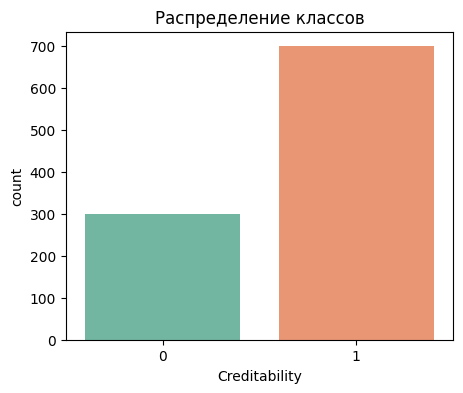

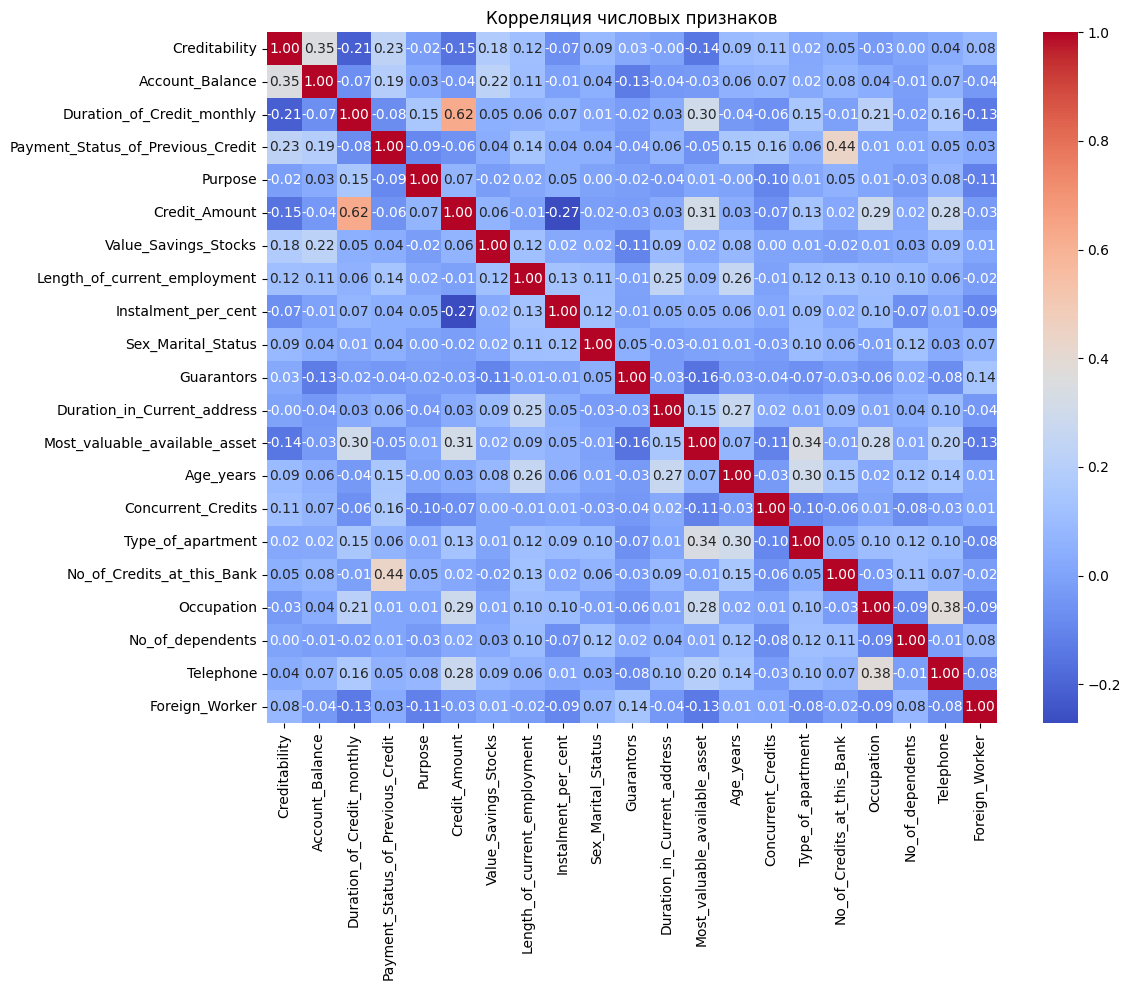

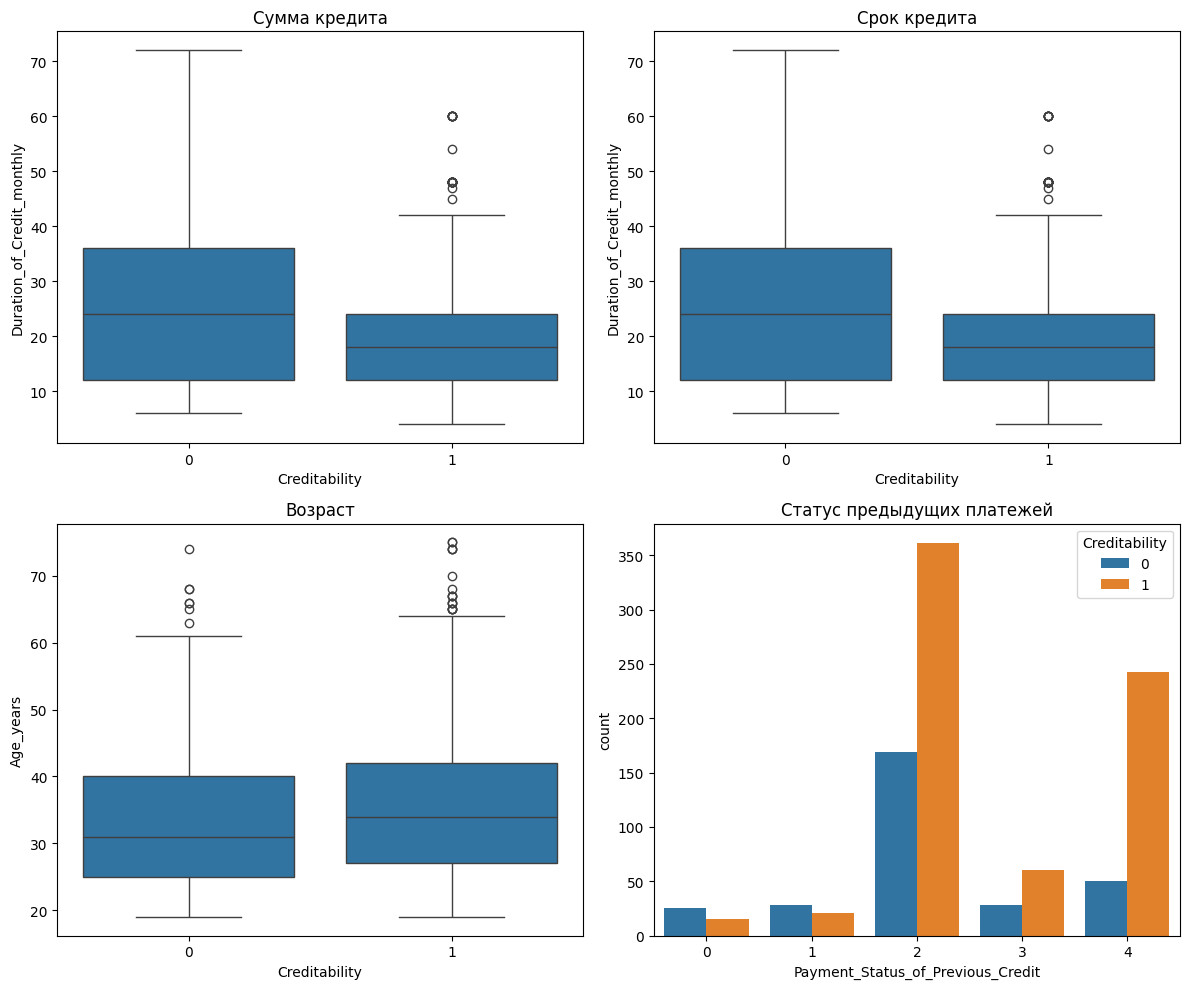

In [8]:
# Целевая переменная
print(data['Creditability'].value_counts(normalize=True))

# Визуализация дисбаланса классов
plt.figure(figsize=(5, 4))
sns.countplot(x='Creditability', data=data, palette='Set2')
plt.title('Распределение классов')
plt.show()

# Корреляционная матрица (для числовых признаков)
numeric_cols = data.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 10))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

# Анализ важных признаков
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(x='Creditability', y='Duration_of_Credit_monthly', data=data, ax=axes[0,0])
axes[0,0].set_title('Сумма кредита')
sns.boxplot(x='Creditability', y='Duration_of_Credit_monthly', data=data, ax=axes[0,1])
axes[0,1].set_title('Срок кредита')
sns.boxplot(x='Creditability', y='Age_years', data=data, ax=axes[1,0])
axes[1,0].set_title('Возраст')
sns.countplot(x='Payment_Status_of_Previous_Credit', hue='Creditability', data=data, ax=axes[1,1])
axes[1,1].set_title('Статус предыдущих платежей')
plt.tight_layout()
plt.show()

Предобработка данных. Числовые признаки масштабируем, категориальные кодируем. Это требование для MLP и улучшения работы ансамблей.

In [9]:
# Разделение признаков и целевой переменной
X = data.drop('Creditability', axis=1)
y = data['Creditability']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Определение типов признаков
categorical_cols = ['Purpose', 'Value_Savings_Stocks', 'Sex_Marital_Status',
                    'Guarantors', 'Most_valuable_available_asset', 'Type_of_apartment',
                    'Occupation', 'Telephone', 'Foreign_Worker']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Предобработка: масштабирование числовых + one-hot для категориальных
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

# Применение предобработки
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Размерность после обработки: {X_train_processed.shape}")

Размерность после обработки: (800, 39)


Базовые модели (Baseline). Обучаем три модели с параметрами по умолчанию. Сравниваем ROC-AUC для выбора направления оптимизации.

In [10]:
# Функция для оценки моделей
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    metrics = {
        'Model': model_name,
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    }
    return metrics, y_proba

results = []

# 1. Random Forest (baseline)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_processed, y_train)
metrics_rf, rf_proba = evaluate_model(rf, X_test_processed, y_test, 'RF_baseline')
results.append(metrics_rf)
print(f"RF baseline: AUC = {metrics_rf['ROC-AUC']:.3f}")

# 2. Gradient Boosting (baseline)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_processed, y_train)
metrics_gb, gb_proba = evaluate_model(gb, X_test_processed, y_test, 'GB_baseline')
results.append(metrics_gb)
print(f"GB baseline: AUC = {metrics_gb['ROC-AUC']:.3f}")

# 3. MLP (baseline)
mlp = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42, early_stopping=True)
mlp.fit(X_train_processed, y_train)
metrics_mlp, mlp_proba = evaluate_model(mlp, X_test_processed, y_test, 'MLP_baseline')
results.append(metrics_mlp)
print(f"MLP baseline: AUC = {metrics_mlp['ROC-AUC']:.3f}")

# Сводная таблица
results_df = pd.DataFrame(results)
print("\n📊 Сравнение моделей:")
print(results_df.sort_values('ROC-AUC', ascending=False).to_string(index=False))

RF baseline: AUC = 0.811
GB baseline: AUC = 0.824
MLP baseline: AUC = 0.620

📊 Сравнение моделей:
       Model  ROC-AUC  Accuracy  Precision   Recall       F1
 GB_baseline 0.823929     0.805   0.817610 0.928571 0.869565
 RF_baseline 0.811369     0.760   0.783951 0.907143 0.841060
MLP_baseline 0.619762     0.620   0.780702 0.635714 0.700787


Подбор гиперпараметров (GridSearch). Автоматически перебираем параметры, чтобы максимизировать ROC-AUC. Фиксируем лучшие комбинации для каждой модели.

In [11]:
# Random Forest - оптимизация
param_grid_rf = {
    'n_estimators': [150, 200],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train_processed, y_train)
print(f"Лучшие параметры RF: {grid_rf.best_params_}")
print(f"Лучший CV AUC: {grid_rf.best_score_:.3f}")

rf_optimized = grid_rf.best_estimator_
metrics_rf_opt, rf_opt_proba = evaluate_model(rf_optimized, X_test_processed, y_test, 'RF_optimized')
results.append(metrics_rf_opt)

# Gradient Boosting - оптимизация
param_grid_gb = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_gb.fit(X_train_processed, y_train)
print(f"Лучшие параметры GB: {grid_gb.best_params_}")
print(f"Лучший CV AUC: {grid_gb.best_score_:.3f}")

gb_optimized = grid_gb.best_estimator_
metrics_gb_opt, gb_opt_proba = evaluate_model(gb_optimized, X_test_processed, y_test, 'GB_optimized')
results.append(metrics_gb_opt)

# MLP - оптимизация
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True, random_state=42),
    param_grid_mlp, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_mlp.fit(X_train_processed, y_train)
print(f"Лучшие параметры MLP: {grid_mlp.best_params_}")
print(f"Лучший CV AUC: {grid_mlp.best_score_:.3f}")

mlp_optimized = grid_mlp.best_estimator_
metrics_mlp_opt, mlp_opt_proba = evaluate_model(mlp_optimized, X_test_processed, y_test, 'MLP_optimized')
results.append(metrics_mlp_opt)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Лучшие параметры RF: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Лучший CV AUC: 0.793
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Лучшие параметры GB: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 150, 'subsample': 0.8}
Лучший CV AUC: 0.776
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Лучшие параметры MLP: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}
Лучший CV AUC: 0.777


Ансамблирование. Объединяем прогнозы нескольких моделей. Это снижает дисперсию ошибок и часто даёт прирост метрик.

In [12]:
# Мягкое голосование (soft voting)
voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_optimized),
        ('gb', gb_optimized),
        ('mlp', mlp_optimized)
    ],
    voting='soft'
)
voting_clf.fit(X_train_processed, y_train)
metrics_voting, voting_proba = evaluate_model(voting_clf, X_test_processed, y_test, 'Voting_Ensemble')
results.append(metrics_voting)
print(f"Voting Ensemble AUC: {metrics_voting['ROC-AUC']:.3f}")

# Усреднение вероятностей (ещё один подход)
ensemble_proba = (rf_opt_proba + gb_opt_proba + mlp_opt_proba) / 3
ensemble_auc = roc_auc_score(y_test, ensemble_proba)
print(f"Average_proba Ensemble AUC: {ensemble_auc:.3f}")

Voting Ensemble AUC: 0.830
Average_proba Ensemble AUC: 0.830


Визуализация результатов

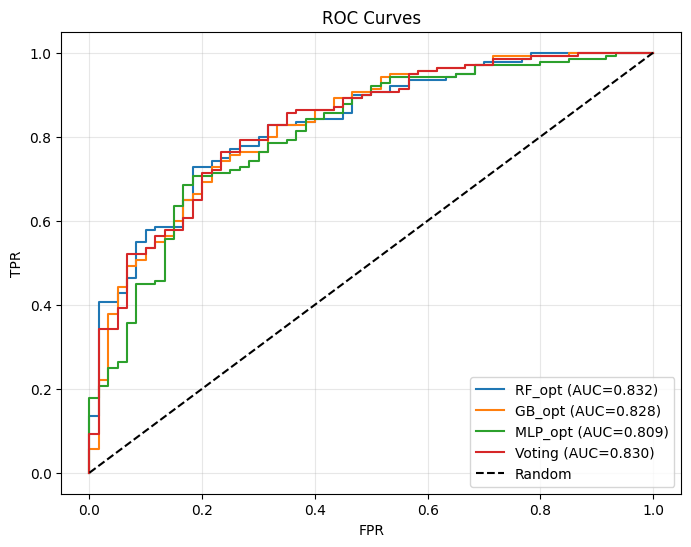

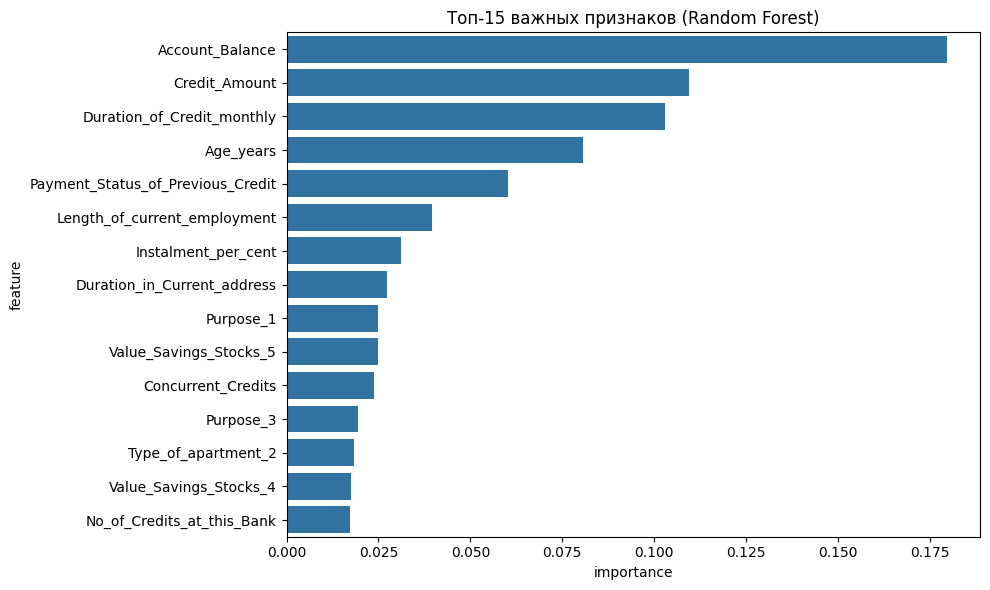


🏆 Итоговые результаты:
          Model  ROC-AUC  Accuracy  Precision   Recall       F1
   RF_optimized 0.831905     0.775   0.841727 0.835714 0.838710
Voting_Ensemble 0.830238     0.790   0.840278 0.864286 0.852113
   GB_optimized 0.828333     0.790   0.818182 0.900000 0.857143
    GB_baseline 0.823929     0.805   0.817610 0.928571 0.869565
    RF_baseline 0.811369     0.760   0.783951 0.907143 0.841060
  MLP_optimized 0.809405     0.770   0.835714 0.835714 0.835714
   MLP_baseline 0.619762     0.620   0.780702 0.635714 0.700787


In [13]:
# 1. ROC-кривые
plt.figure(figsize=(8, 6))
for name, proba in [('RF_opt', rf_opt_proba), ('GB_opt', gb_opt_proba),
                     ('MLP_opt', mlp_opt_proba), ('Voting', voting_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2. Важность признаков (для RF)
importances = rf_optimized.feature_importances_
feature_names = (numerical_cols +
                 list(preprocessor.named_transformers_['cat']
                 .get_feature_names_out(categorical_cols)))
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp)
plt.title('Топ-15 важных признаков (Random Forest)')
plt.tight_layout()
plt.show()

# 3. Финальная таблица метрик
final_results = pd.DataFrame(results)
print("\n🏆 Итоговые результаты:")
print(final_results.sort_values('ROC-AUC', ascending=False).to_string(index=False))

### Выводы:

1. **Какая модель показала лучший ROC-AUC?**
    RF_optimized 0.831905

2. **Почему масштабирование важно для MLP?**
   Нейросети чувствительны к масштабу признаков. Без стандартизации градиентный спуск сходится медленнее, веса обучаются нестабильно.

3. **Как обрабатывали дисбаланс классов?**
   Использовали `class_weight='balanced'` в RF, также применяли stratify при разделении выборки.

4. **Какие гиперпараметры наиболее влияют на качество?**
   Для ансамблей: `n_estimators`, `max_depth`, `learning_rate` (GB). для MLP: `hidden_layer_sizes`, `alpha`, `activation`.

5. **Почему ансамбли часто лучше одиночных моделей?**
   Ансамбли уменьшают дисперсию или смещение, усредняя ошибки отдельных моделей.